# Linear model: ElastictNet

This model gave the best score (Ranking 656) do to the important linear relationships we have in our variables (see EDA) and the regularisation offered by ElasticNet that linearly combines the L 1 and L 2 penalties of the lasso and ridge methods.

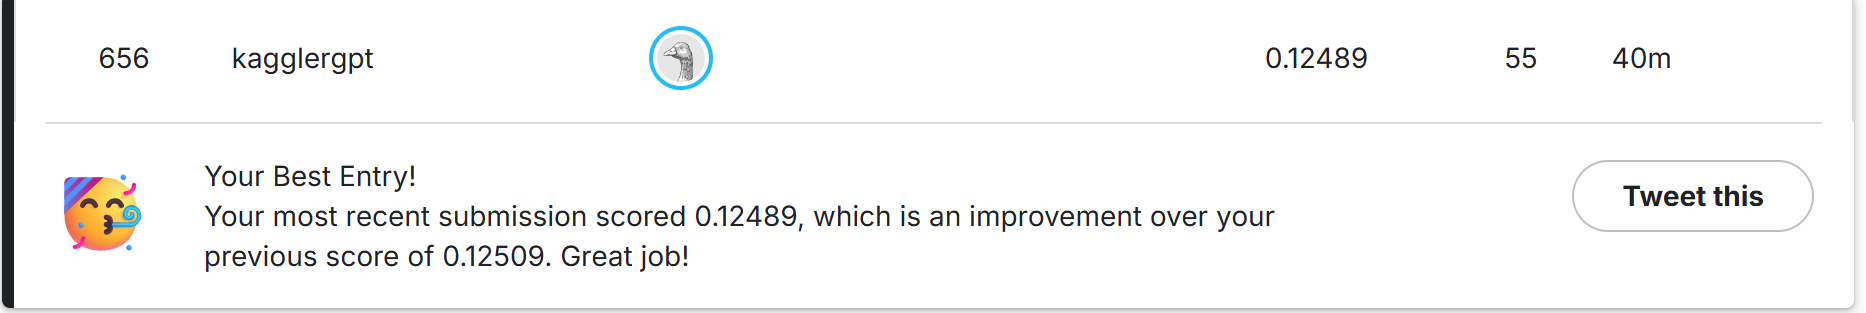

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import plotly.express as px
import seaborn as sns

# Load dataset
df = pd.read_csv('train.csv') 


## 1.1 convert types

Its better to convert categorical variables to "category" to save memory, but since there are a few we convert to object for generic and simple handeling 

In [2]:
df[['Id', 'MSSubClass', 'MoSold', 'YearBuilt', 'YearRemodAdd', 'YrSold']] = df[['Id', 'MSSubClass', 'MoSold', 'YearBuilt', 'YearRemodAdd', 'YrSold']].astype('object')

## 1.3 Fill missing values with "Missing" for categorical variables

We keep variables with a lots of missing values because they are handeled well with regularisation

In [4]:
# Identify categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# Fill missing values with "Missing"
df[cat_cols] = df[cat_cols].fillna("Missing")



C:\Users\berra\AppData\Local\Temp\ipykernel_22460\1901938063.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cat_cols] = df[cat_cols].fillna("Missing")


## 1.4 Fill missing values with the mean for quantitative variables

In [5]:
#save numeric means for missing test values
means = df.select_dtypes(include='number').mean()

#imputer numeric par moyenne dans train
df = df.fillna(df.select_dtypes(include='number').mean())

## 1.5 create variables for clarity HouseAge, YearsSinceRemod...

In [6]:
df_dropped = df.copy()

#'YearBuilt', 'YearRemodAdd, 'MoSold', 'YrSold' convert to quantitative
# List of columns to convert
columns_to_convert = ['YearBuilt', 'YearRemodAdd', 'MoSold', 'YrSold']

# Convert each to integer safely
for col in columns_to_convert:
    df_dropped.loc[:, col] = df_dropped[col].astype(int)

# Set reference year
reference_year = df_dropped['YrSold'].max()

# Create quantitative features safely
df_dropped.loc[:, 'HouseAge'] = reference_year - df_dropped['YearBuilt']
df_dropped.loc[:, 'YearsSinceRemod'] = reference_year -df_dropped['YearRemodAdd']
df_dropped.loc[:, 'TimeIndex'] = (
    (df_dropped['YrSold'] - df_dropped['YrSold'].min()) * 12 + df_dropped['MoSold']
)

df_dropped = df_dropped.drop([
    'YearBuilt', 'YearRemodAdd', 'YrSold', 'MoSold'
], axis=1) 

# Convert object columns to numeric, forcing errors to NaN
cols_to_convert = ['HouseAge', 'YearsSinceRemod', 'TimeIndex']
df_dropped[cols_to_convert] = df_dropped[cols_to_convert].apply(pd.to_numeric, errors='coerce')

## Transform categorical variables

MSSubclass seems to be an important variable, it correlates well with SalePrice (see box plots, medium, variance in eda notebook). For example: 60( 2-STORY 1946 & NEWER) and 120 (1-STORY PUD (Planned Unit Development) - 1946 & NEWER) seem to have very high prices (domaine knowledge explain that well). We can create less sparse variables using these elements: category size, correlation with price, domain knoledge. This will give us 3 principal variables.

In [7]:
percentages = df['MSSubClass'].value_counts(normalize=True) * 100
print(percentages)

ms = df["MSSubClass"]

df["story_group"] = np.where(ms.isin([20, 30, 40, 120]), "1", "more")
df["is_pud"]      = ms.isin([120, 150, 160, 180]).astype("int8")
df["age_band"]    = np.select(
    [ms.isin([20, 60, 120, 160]), ms.isin([30, 70])],
    ["new", "old"],
    default="all"
)

MSSubClass
20     36.712329
60     20.479452
50      9.863014
120     5.958904
30      4.726027
160     4.315068
70      4.109589
80      3.972603
90      3.561644
190     2.054795
85      1.369863
75      1.095890
45      0.821918
180     0.684932
40      0.273973
Name: proportion, dtype: float64


## 1.6 Correct skewness

For variables with a significant skewness from the test pandas.DataFrame.skew()

In [8]:
#case 1: only binary no log

#Most houses don't have low-quality finished square footage.
#Very few do, with highly varied amounts.
cols_to_binary_only_0 = ['BsmtHalfBath', 'EnclosedPorch', 'ScreenPorch']

for col in cols_to_binary_only_0:
    df_dropped[f'Has{col}'] = (df_dropped[col] > 0).astype(int)
    df_dropped.drop(columns=[col], inplace=True)

# = 1 or not

df_dropped['HasKitchen'] = (df_dropped['KitchenAbvGr'] == 1).astype(int)
df_dropped.drop(columns=['KitchenAbvGr'], inplace=True)


#case 2: binary+log

cols = ['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', '2ndFlrSF', 'WoodDeckSF', 'OpenPorchSF']  # Replace with actual column names

for col in cols:
    df_dropped[f'Has{col}'] = (df_dropped[col] > 0).astype(int)
    df_dropped[f'{col}_log'] = np.log1p(df_dropped[col])

#case 3: just drop 
df_dropped.drop(columns=['LowQualFinSF','3SsnPorch', 'PoolArea', 'MiscVal'], inplace=True)

# case 4: log only

df_dropped.drop(columns=[ 'TimeIndex'], inplace=True)# cyclique, pas significative

# List of variables to transform
vars_to_log = ['LotFrontage', 'LotArea', 'TotalBsmtSF', 'GrLivArea',  'SalePrice', 'BsmtUnfSF', '1stFlrSF']

# Create log-transformed versions with "_log" suffix
for col in vars_to_log:
    df_dropped[col + '_log'] = np.log1p(df_dropped[col])  # log1p handles zero safely

# Drop the original columns
df_dropped.drop(columns=vars_to_log, inplace=True)

## 1.7 Cap outliers

In [9]:
# cap outliers
#outliers cap

num_features = [col for col in df_dropped.select_dtypes(include='number') if col != 'Id']
 
# Store the limits for each column
caps = {}

for col in num_features:
    q_low = df_dropped[col].quantile(0.01)
    q_high = df_dropped[col].quantile(0.99)
    
    # Save the thresholds
    caps[col] = (q_low, q_high)
    
    # Apply clipping
    df_dropped[col] = df_dropped[col].clip(lower=q_low, upper=q_high)



### Rare categories

They are handeled well with regularisation, we can keep them in our data as they are



### Scaling

In [ ]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,RobustScaler

y_avant = df_dropped['SalePrice_log']
df_dropped[[ 'MSSubClass']] = df_dropped[[ 'MSSubClass']].astype('object')

# Select float and int columns, excluding 'Id'
cols_to_scale = df_dropped.select_dtypes(include=['float', 'int']).columns.drop(['Id', 'SalePrice_log'])
scaler = RobustScaler()
# Apply RobustScaler
df_dropped[cols_to_scale] = scaler.fit_transform(df_dropped[cols_to_scale])

In [13]:
# One-hot encode all object or category dtype columns
df_dropped = pd.get_dummies(df_dropped, drop_first=False)

### Predict

In [ ]:

from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


# Step 1: Separate features and target
X_train = df_dropped.drop(columns=['Id', 'SalePrice_log'])  # Replace 'Price' with your actual target if named differently

y = y_avant


# 5. ElasticNetCV model with cross-validation (no pipeline/scaler)
import numpy as np
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error

alphas = np.logspace(-4, 4, 50)
l1_ratios = [0.05, 0.15, 0.3, 0.5, 0.7, 0.85, 0.95, 1.0]

enet_cv = ElasticNetCV(
    alphas=alphas,
    l1_ratio=l1_ratios,
    cv=5,
    max_iter=10000,
    n_jobs=-1,
    random_state=42
)

enet_cv.fit(X_train, y)

print(f"Best alpha (ElasticNetCV): {enet_cv.alpha_:.6g}")
print(f"Best l1_ratio: {enet_cv.l1_ratio_}")


# Optional: sparsity
coef = enet_cv.coef_
print(f"Non-zero coefficients: {(coef != 0).sum()} / {coef.size}")


In [18]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from scipy import sparse

# ---------- 0) Names & shapes ----------
if isinstance(X_train, pd.DataFrame):
    feature_names = X_train.columns.to_list()
else:
    feature_names = [f"x{i}" for i in range(X_train.shape[1])]

coef = np.asarray(enet_cv.coef_)          # (n_features,) or (n_targets, n_features)
intercept = enet_cv.intercept_            # scalar or (n_targets,)
print("coef_.shape:", coef.shape)

best_alpha = getattr(enet_cv, "alpha_", None)
best_l1 = getattr(enet_cv, "l1_ratio_", getattr(enet_cv, "l1_ratio", None))

# ---------- robust column-wise std ----------
def col_std(X):
    """Population SD per column; supports dense and CSR/CSC sparse."""
    if sparse.issparse(X):
        # E[X], E[X^2]
        mu = np.asarray(X.mean(axis=0)).ravel()
        ex2 = np.asarray(X.multiply(X).mean(axis=0)).ravel()
        var = ex2 - mu**2
        var[var < 0] = 0.0  # numerical guard
        return np.sqrt(var)
    else:
        X_arr = np.asarray(X, dtype=float)
        return X_arr.std(axis=0, ddof=0)

x_sd = col_std(X_train)

# ---------- y SD(s) ----------
y_arr = np.asarray(y)
if y_arr.ndim == 1:
    y_sd = y_arr.std(ddof=0) or 1.0
    y_names = ["y"]
else:
    y_sd = y_arr.std(axis=0, ddof=0)
    y_sd[y_sd == 0] = 1.0
    if isinstance(y, pd.DataFrame):
        y_names = y.columns.to_list()
    else:
        y_names = [f"y{i}" for i in range(y_arr.shape[1])]


coef_.shape: (324,)


In [19]:
# ---------- 1) Coefficients & standardized betas ----------
if coef.ndim == 1:
    # Single-target
    if len(feature_names) != coef.shape[0]:
        raise ValueError(f"feature_names has length {len(feature_names)} but model has {coef.shape[0]} features.")

    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coef": coef,
    })
    coef_df["abs_coef"] = coef_df["coef"].abs()
    coef_df["x_sd"] = x_sd
    coef_df["std_beta"] = coef_df["coef"] * x_sd / y_sd

    nonzero_mask = coef_df["coef"].to_numpy() != 0
    print(f"Non-zero coefficients: {nonzero_mask.sum()} / {coef.size}")
    print(f"Intercept: {float(intercept):.4g}")
    print(f"Best alpha: {best_alpha} | Best l1_ratio: {best_l1}")

    # Top by standardized effect
    top_n = 15
    ranked_std = (coef_df.loc[nonzero_mask]
                           .reindex(coef_df.loc[nonzero_mask, "std_beta"].abs().sort_values(ascending=False).index))

    print("\nTop features by standardized effect (per +1 SD in X):")
    print(ranked_std.head(top_n)[["feature", "std_beta", "coef", "x_sd"]].to_string(index=False))

    top_pos = ranked_std[ranked_std["std_beta"] > 0].head(10)
    top_neg = ranked_std[ranked_std["std_beta"] < 0].head(10)
    print("\nStrongest positive effects:")
    print(top_pos[["feature", "std_beta", "coef"]].to_string(index=False))
    print("\nStrongest negative effects:")
    print(top_neg[["feature", "std_beta", "coef"]].to_string(index=False))

else:
    # Multi-target: build a long table with a target column
    n_targets, n_features = coef.shape
    if len(feature_names) != n_features:
        raise ValueError(f"feature_names has {len(feature_names)} entries, but model has {n_features} features after preprocessing.")

    rows = []
    for t_idx, t_name in enumerate(y_names):
        std_beta_t = coef[t_idx] * x_sd / y_sd[t_idx]
        for f_idx, f_name in enumerate(feature_names):
            c = coef[t_idx, f_idx]
            rows.append((t_name, f_name, c, abs(c), x_sd[f_idx], std_beta_t[f_idx]))

    coef_df = pd.DataFrame(rows, columns=["target", "feature", "coef", "abs_coef", "x_sd", "std_beta"])

    # Print quick summary per target
    print(f"Detected multi-output with {len(y_names)} targets. Intercept(s): {intercept}")
    print(f"Best alpha: {best_alpha} | Best l1_ratio: {best_l1}")

    top_n = 15
    for t_name in y_names:
        sub = coef_df[coef_df["target"] == t_name]
        nonzero_mask = sub["coef"].to_numpy() != 0
        print(f"\n[{t_name}] Non-zero coefficients: {nonzero_mask.sum()} / {sub.shape[0]}")
        ranked_std = (sub.loc[nonzero_mask]
                         .reindex(sub.loc[nonzero_mask, "std_beta"].abs().sort_values(ascending=False).index))
        print(f"\n[{t_name}] Top features by standardized effect (per +1 SD in X):")
        print(ranked_std.head(top_n)[["feature", "std_beta", "coef", "x_sd"]].to_string(index=False))

        top_pos = ranked_std[ranked_std["std_beta"] > 0].head(10)
        top_neg = ranked_std[ranked_std["std_beta"] < 0].head(10)
        print(f"\n[{t_name}] Strongest positive effects:")
        print(top_pos[["feature", "std_beta", "coef"]].to_string(index=False))
        print(f"\n[{t_name}] Strongest negative effects:")
        print(top_neg[["feature", "std_beta", "coef"]].to_string(index=False))

Non-zero coefficients: 104 / 324
Intercept: 11.83
Best alpha: 0.0006551285568595509 | Best l1_ratio: 0.85

Top features by standardized effect (per +1 SD in X):
             feature  std_beta      coef     x_sd
       GrLivArea_log  0.296354  0.160331 0.713878
         OverallQual  0.173515  0.097905 0.684488
            HouseAge -0.141043 -0.084097 0.647742
         OverallCond  0.124537  0.043788 1.098450
         LotArea_log  0.083829  0.028320 1.143219
        1stFlrSF_log  0.071293  0.040540 0.679198
          GarageCars  0.069021  0.036069 0.739065
          BsmtFinSF1  0.065481  0.041998 0.602179
     TotalBsmtSF_log  0.056140  0.009277 2.337176
      Functional_Typ  0.051113  0.078154 0.252590
Neighborhood_Crawfor  0.047810  0.100569 0.183606
     Condition1_Norm  0.045869  0.051523 0.343833
            2ndFlrSF  0.044446  0.029017 0.591579
Neighborhood_NridgHt  0.037978  0.065624 0.223513
         MSZoning_RM -0.036555 -0.039613 0.356399

Strongest positive effects:
          

# Test set

In [20]:
# test

d_test = pd.read_csv('test.csv') 

## 2.1 convert types

In [22]:
d_test[['Id', 'MSSubClass', 'MoSold', 'YearBuilt', 'YearRemodAdd', 'YrSold']] = d_test[['Id', 'MSSubClass', 'MoSold', 'YearBuilt', 'YearRemodAdd', 'YrSold']].astype('object')

In [23]:
ms = d_test["MSSubClass"]

d_test["story_group"] = np.where(ms.isin([20, 30, 40, 120]), "1", "more")
d_test["is_pud"]      = ms.isin([120, 150, 160, 180]).astype("int8")
d_test["age_band"]    = np.select(
    [ms.isin([20, 60, 120, 160]), ms.isin([30, 70])],
    ["new", "old"],
    default="all"
)

## 2.3 Fill missing values with "Missing" for categorical variables

In [24]:

# Identify categorical columns
cat_cols = d_test.select_dtypes(include=['object', 'category']).columns

# Fill missing values with "Missing"
d_test[cat_cols] = d_test[cat_cols].fillna("Missing")


C:\Users\berra\AppData\Local\Temp\ipykernel_22460\3436678766.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d_test[cat_cols] = d_test[cat_cols].fillna("Missing")


## 2.4 Fill missing values with the mean for quantitative variables from the train

In [25]:
# Imputation dans le test set (numeric)
d_test.fillna(means, inplace=True)

## 2.5 create variables like the train

In [26]:
#'YearBuilt', 'YearRemodAdd, 'MoSold', 'YrSold' convert to quantitative
# List of columns to convert
columns_to_convert = ['YearBuilt', 'YearRemodAdd', 'MoSold', 'YrSold']

# Convert each to integer safely
for col in columns_to_convert:
    d_test.loc[:, col] = d_test[col].astype(int)

# Set reference year
reference_year = d_test['YrSold'].max()

# Create quantitative features safely
d_test.loc[:, 'HouseAge'] = reference_year - d_test['YearBuilt']
d_test.loc[:, 'YearsSinceRemod'] = reference_year - d_test['YearRemodAdd']


d_test = d_test.drop([
    'YearBuilt', 'YearRemodAdd', 'YrSold', 'MoSold'
], axis=1) 

# Convert object columns to numeric, forcing errors to NaN
cols_to_convert = ['HouseAge', 'YearsSinceRemod']
d_test[cols_to_convert] = d_test[cols_to_convert].apply(pd.to_numeric, errors='coerce')

## 2.6 Correct skewness

In [27]:
#case 1: only binary no log

#Most houses don't have low-quality finished square footage.
#Very few do, with highly varied amounts.
cols_to_binary_only_0 = ['BsmtHalfBath', 'EnclosedPorch', 'ScreenPorch']

for col in cols_to_binary_only_0:
    d_test[f'Has{col}'] = (d_test[col] > 0).astype(int)
    d_test.drop(columns=[col], inplace=True)

# = 1 or not

d_test['HasKitchen'] = (d_test['KitchenAbvGr'] == 1).astype(int)
d_test.drop(columns=['KitchenAbvGr'], inplace=True)


#case 2: binary+log

cols = ['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', '2ndFlrSF', 'WoodDeckSF', 'OpenPorchSF']  # Replace with actual column names

for col in cols:
    d_test[f'Has{col}'] = (d_test[col] > 0).astype(int)
    d_test[f'{col}_log'] = np.log1p(d_test[col])

#case 3: just drop 
d_test.drop(columns=['LowQualFinSF','3SsnPorch', 'PoolArea', 'MiscVal'], inplace=True)

# case 4: log only

# List of variables to transform
vars_to_log = ['LotFrontage', 'LotArea', 'TotalBsmtSF', 'GrLivArea',  'BsmtUnfSF', '1stFlrSF']


# Create log-transformed versions with "_log" suffix
for col in vars_to_log:
    d_test[col + '_log'] = np.log1p(d_test[col])  # log1p handles zero safely

# Drop the original columns
d_test.drop(columns=vars_to_log, inplace=True)

## 2.7 Cap outliers

In [28]:
num_features = [col for col in num_features if col != "SalePrice_log"]

for col in num_features:
    q_low, q_high = caps[col]
    d_test[col] = d_test[col].clip(lower=q_low, upper=q_high)


### Scaling

In [29]:


d_test[[ 'MSSubClass']] = d_test[[ 'MSSubClass']].astype('object')
#d_test[d_test.select_dtypes(include='float').columns] = RobustScaler().fit_transform(d_test[d_test.select_dtypes(include='float').columns])
cols_to_scale = d_test.select_dtypes(include=['float', 'int']).columns.drop(['Id'])
d_test[cols_to_scale] = scaler.transform(d_test[cols_to_scale])

# 2.9 predict

In [30]:
# One-hot encode all object or category dtype columns
d_test = pd.get_dummies(d_test, drop_first=False)

X_test = d_test.drop(columns=['Id'], errors='ignore') 
# Align with training columns (very important!)
X_test_aligned = X_test.reindex(columns=X_train.columns, fill_value=0)

y_pred_log = enet_cv.predict(X_test_aligned)
y_pred = np.expm1(y_pred_log)  # reverse np.log1p()
d_test['SalePrice'] = y_pred
d_test[['Id', 'SalePrice']].to_csv("predictions_linear.csv", index=False)

In [31]:
# ---------- 2) Permutation importance (on TEST set) ----------
# For multi-output estimators, default R^2 scoring averages across targets.
perm = permutation_importance(
    enet_cv, X_test_aligned, y_pred_log, n_repeats=20, random_state=42, n_jobs=-1
)
perm_df = pd.DataFrame({
    "feature": feature_names,
    "perm_importance_mean": perm.importances_mean,
    "perm_importance_std": perm.importances_std
}).sort_values("perm_importance_mean", ascending=False)

print("\nTop features by permutation importance on the test set:")
print(perm_df.head(15).to_string(index=False))


Top features by permutation importance on the test set:
             feature  perm_importance_mean  perm_importance_std
       GrLivArea_log              0.165098             0.004006
         OverallQual              0.066395             0.001430
            HouseAge              0.042562             0.000881
         OverallCond              0.030769             0.000744
         LotArea_log              0.014745             0.000366
        1stFlrSF_log              0.011100             0.000375
          GarageCars              0.010256             0.000340
          BsmtFinSF1              0.009061             0.000266
     TotalBsmtSF_log              0.007256             0.000142
      Functional_Typ              0.005537             0.000149
Neighborhood_Crawfor              0.004791             0.000119
     Condition1_Norm              0.004488             0.000144
            2ndFlrSF              0.003734             0.000094
Neighborhood_NridgHt              0.003422     